In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,  
})

In [2]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')
model = BertModel.from_pretrained('bert-large-uncased')

embeddings = model.embeddings.word_embeddings.weight.detach().numpy()

text = 'As Gregor Samsa awoke one morning from uneasy dreams he found himself transformed in his bed into a gigantic bug'

tokens = tokenizer.encode(text, add_special_tokens=False)

print(f'There are {len(tokens)} tokens in the text, {len(set(tokens))} of which are unique.\n')

for t in tokens:
    print(f'Token index {t:5} is "tokenizer.decode(t)"')

c:\Users\PauloOliveira\py_studies\ml4llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\PauloOliveira\py_studies\ml4llm\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PauloOliveira\.cache\huggingface\hub\models--bert-large-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator.

There are 21 tokens in the text, 21 of which are unique.

Token index  2004 is "tokenizer.decode(t)"
Token index 16973 is "tokenizer.decode(t)"
Token index  3520 is "tokenizer.decode(t)"
Token index  3736 is "tokenizer.decode(t)"
Token index 19179 is "tokenizer.decode(t)"
Token index  2028 is "tokenizer.decode(t)"
Token index  2851 is "tokenizer.decode(t)"
Token index  2013 is "tokenizer.decode(t)"
Token index 15491 is "tokenizer.decode(t)"
Token index  5544 is "tokenizer.decode(t)"
Token index  2002 is "tokenizer.decode(t)"
Token index  2179 is "tokenizer.decode(t)"
Token index  2370 is "tokenizer.decode(t)"
Token index  8590 is "tokenizer.decode(t)"
Token index  1999 is "tokenizer.decode(t)"
Token index  2010 is "tokenizer.decode(t)"
Token index  2793 is "tokenizer.decode(t)"
Token index  2046 is "tokenizer.decode(t)"
Token index  1037 is "tokenizer.decode(t)"
Token index 20193 is "tokenizer.decode(t)"
Token index 11829 is "tokenizer.decode(t)"


In [3]:
E = embeddings[tokens, :]

E_norm = E / np.linalg.norm(E, axis=1, keepdims=True)

csM = E_norm @ E_norm.T

uniqueCS = csM[np.nonzero(np.triu(csM, 1))]

thresh = np.median(uniqueCS) + np.std(uniqueCS)

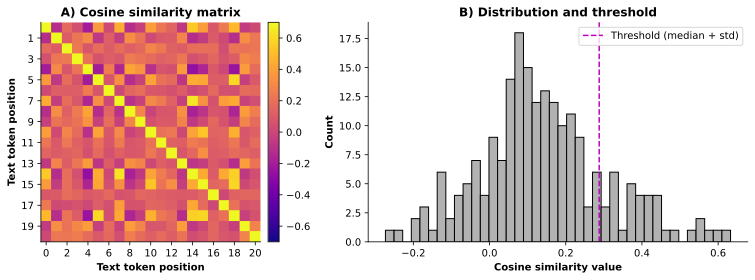

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))

h = axs[0].imshow(csM, vmin=-0.7, vmax=0.7, cmap='plasma')
axs[0].set(xlabel='Text token position', ylabel='Text token position', xticks=range(0, len(tokens), 2), yticks=range(1, len(tokens), 2), title='A) Cosine similarity matrix')
fig.colorbar(h, ax=axs[0], fraction=0.046, pad=0.02)

axs[1].hist(uniqueCS, bins=40, color=[.7,.7,.7], edgecolor='k')
axs[1].axvline(thresh, linestyle='--', color='m', label='Threshold (median + std)')

axs[1].legend()
axs[1].set(xlabel='Cosine similarity value',ylabel='Count',title='B) Distribution and threshold')

plt.tight_layout()
plt.savefig('ch3_proj11_part1.png')
plt.show()

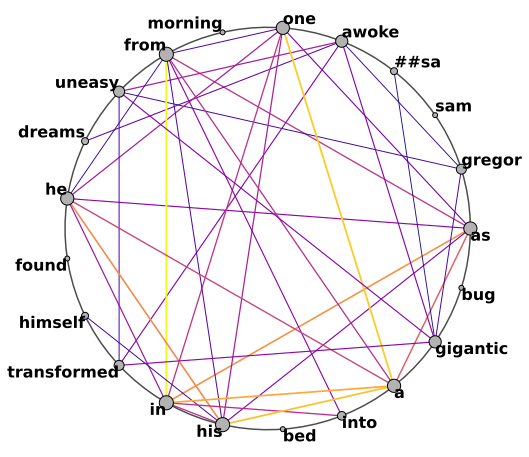

In [7]:
N = len(tokens)

th = np.linspace(0, 2*np.pi-2*np.pi/N, N)

maxcs = np.sort(csM[csM<0.99])[-1]

plt.figure(figsize=(8,8))

thHighres = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(thHighres), np.sin(thHighres), color=[.3,.3,.3])

for i in range(N):
    dotsize = 5*np.sqrt((csM[i]>thresh).sum())

    plt.plot(np.cos(th[i]), np.sin(th[i]), 'ko', markerfacecolor=[.7, .7, .7], markersize=dotsize)

    plt.text(np.cos(th[i]),np.sin(th[i]),tokenizer.decode([tokens[i]]), ha=['right','left'][int(np.cos(th[i])>0)], va=['top','bottom'][int(np.sin(th[i])>0)], fontweight='bold',fontsize=16)

    for j in range(i+1, N):
        if csM[i, j] > thresh:
            cidx = (csM[i, j]- thresh) / (maxcs-thresh)
            color = plt.cm.plasma(cidx)

            x_vals = [ np.cos(th[i]), np.cos(th[j])]
            y_vals = [ np.sin(th[i]), np.sin(th[j])]
            plt.plot(x_vals, y_vals, zorder=-10, color=color, linewidth=3*csM[i,j])

plt.axis('off')

plt.savefig('ch3_proj11_part2.png')
plt.show()

In [8]:
text = [str(i) for i in range(10)] + [str(i*10) for i in range(1,11)]
tokens = tokenizer.encode(text, add_special_tokens=False)
tokens = [t[0] for t in tokens]

for t in tokens:
    print(f'{t} is "{tokenizer.decode(t)}"')

1014 is "0"
1015 is "1"
1016 is "2"
1017 is "3"
1018 is "4"
1019 is "5"
1020 is "6"
1021 is "7"
1022 is "8"
1023 is "9"
2184 is "10"
2322 is "20"
2382 is "30"
2871 is "40"
2753 is "50"
3438 is "60"
3963 is "70"
3770 is "80"
3938 is "90"
2531 is "100"


In [9]:
E = embeddings[tokens, :]
E_norm = E / np.linalg.norm(E, axis=1, keepdims=True)
csM = E_norm @ E_norm.T

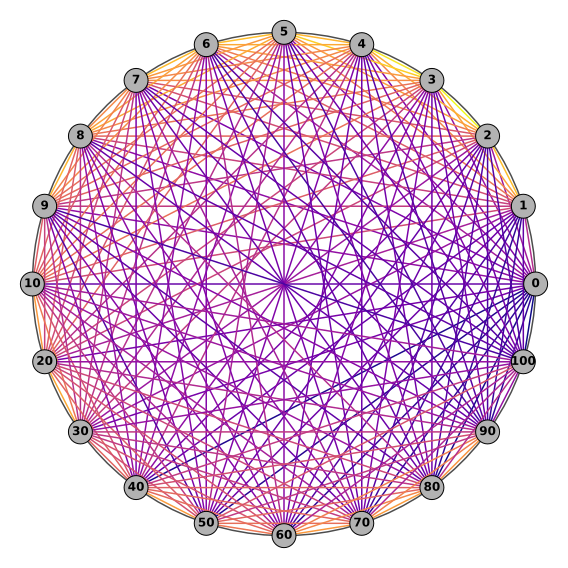

In [11]:
N = len(tokens)
th = np.linspace(0,2*np.pi-2*np.pi*(1/N), N)

maxcs = np.sort(csM[csM<.99])[-1]

plt.figure(figsize=(8,8))

thHighres = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(thHighres), np.sin(thHighres), color=[.3, .3, .3])

for i in range(N):
  plt.plot(np.cos(th[i]),np.sin(th[i]),'ko',markerfacecolor=[.7,.7,.7],markersize=24)

  plt.text(np.cos(th[i]),np.sin(th[i]),tokenizer.decode([tokens[i]]), ha='center',va='center',fontweight='bold',fontsize=12,color='k')

  for j in range(i+1,N):

    cidx = (csM[i,j]-csM.min()) / (maxcs-csM.min())
    color = plt.cm.plasma(cidx)

    x_vals = [ np.cos(th[i]),np.cos(th[j]) ]
    y_vals = [ np.sin(th[i]),np.sin(th[j]) ]
    plt.plot(x_vals,y_vals,zorder=-10,color=color)

plt.axis('off')

plt.tight_layout()
plt.savefig('ch3_proj11_part3.png')
plt.show()